Đang tải dữ liệu MNIST...
-> Kích thước ma trận X gốc: (1000, 784) (1000 ảnh, 784 điểm ảnh)
-> Kích thước Ma trận Hiệp phương sai: (784, 784)
-> Kích thước dữ liệu sau nén: (1000, 2) (Đã ép xuống 2D!)



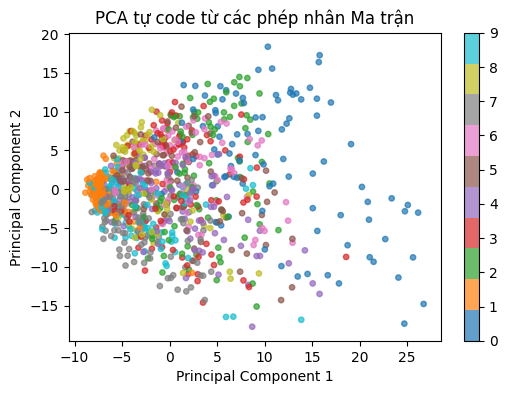

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from keras.datasets import mnist

(x_train, y_train), _ = mnist.load_data()

# chỉ lấy 1000 ảnh để chống crash
X = x_train[:1000].reshape(1000, 784).astype('float32') / 255.
y_small = y_train[:1000]

print(f"-> Kích thước ma trận X gốc: {X.shape}")

# 2. Zero-centered & Standardized - đưa tâm dữ liệu về 0 và var =1
X_std = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

# 3. TÍNH MA TRẬN HIỆP PHƯƠNG SAI (Covariance Matrix)
cov_matrix = np.matmul(X_std.T, X_std) 
print(f"-> Kích thước Ma trận Hiệp phương sai: {cov_matrix.shape}")

# 4. TÌM NGHIỆM VECTOR RIÊNG VÀ GIÁ TRỊ RIÊNG
values, vectors = eigh(cov_matrix, subset_by_index=[782, 783])

# 5. CHIẾU DỮ LIỆU (Projection) - ÉP XUỐNG 2D
new_coordinates = np.matmul(X_std, vectors)
print(f"-> Kích thước dữ liệu sau nén: {new_coordinates.shape} (Đã ép xuống 2D!)\n")

# 6. TRỰC QUAN HÓA THÀNH QUẢ
plt.figure(figsize=(6, 4))
plt.scatter(new_coordinates[:, 1], new_coordinates[:, 0], c=y_small, cmap='tab10', alpha=0.7, s=15)
plt.title("PCA tự code từ các phép nhân Ma trận")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

Đang chạy thuật toán MDS (Tuyến tính)...
Xong! Mất 12.79 giây cho 1000 ảnh.


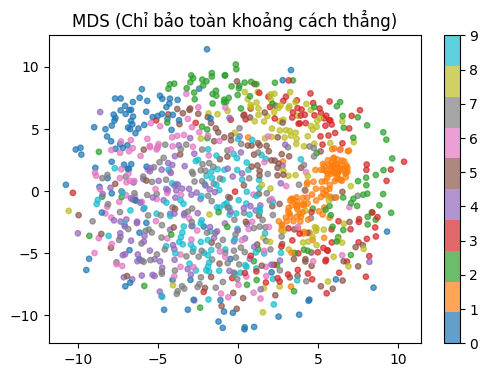

In [ ]:
# ==========================================
# BƯỚC 2: MULTIDIMENSIONAL SCALING (MDS)
# ==========================================
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import time


x_small = x_flat[:1000]
y_small = y_sample[:1000]

start_time = time.time()
mds = MDS(n_components=2, random_state=42)
mds_result = mds.fit_transform(x_small)
print(f"Xong! Mất {time.time() - start_time:.2f} giây cho 1000 ảnh.")

# Trực quan hóa kết quả (Kết quả sẽ tròn xoe và rối rắm y như PCA)
plt.figure(figsize=(6, 4))
plt.scatter(mds_result[:, 0], mds_result[:, 1], c=y_small, cmap='tab10', alpha=0.7, s=15)
plt.title("MDS (Chỉ bảo toàn khoảng cách thẳng)")
plt.colorbar()
plt.show()

Bắt đầu 'gỡ rối' bằng phương pháp Phi tuyến...


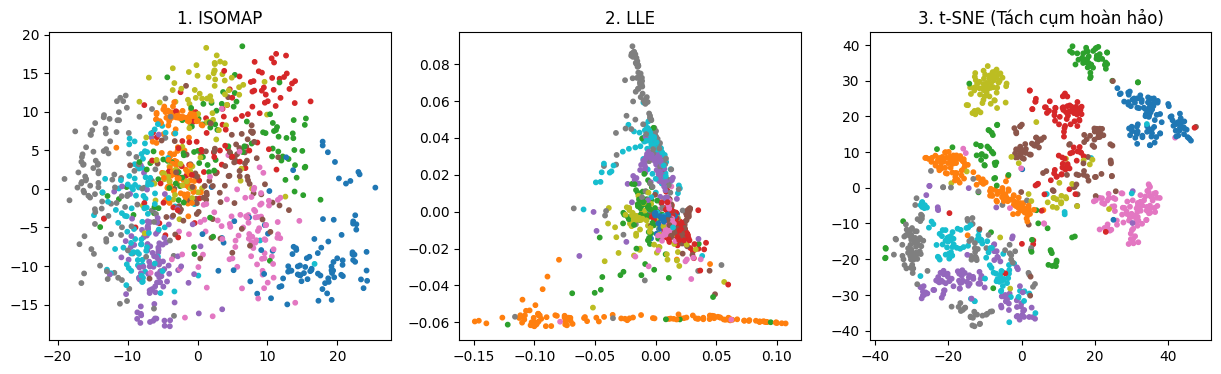

In [25]:
# ==========================================
# BƯỚC 3: CÁC PHƯƠNG PHÁP PHI TUYẾN
# ==========================================
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE

print("Bắt đầu 'gỡ rối' bằng phương pháp Phi tuyến...")

# 1. Isomap (Khoảng cách trắc địa trên đồ thị)
isomap = Isomap(n_components=2, n_neighbors=10)
isomap_result = isomap.fit_transform(x_small)

# 2. LLE (Bảo toàn trọng số hàng xóm cục bộ)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
lle_result = lle.fit_transform(x_small)

# 3. t-SNE (Trùm cuối - Dựa trên phân phối xác suất)
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(x_small)

# Vẽ 3 biểu đồ cạnh nhau để so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(isomap_result[:, 0], isomap_result[:, 1], c=y_small, cmap='tab10', s=10)
axes[0].set_title("1. ISOMAP")

axes[1].scatter(lle_result[:, 0], lle_result[:, 1], c=y_small, cmap='tab10', s=10)
axes[1].set_title("2. LLE")

axes[2].scatter(tsne_result[:, 0], tsne_result[:, 1], c=y_small, cmap='tab10', s=10)
axes[2].set_title("3. t-SNE (Tách cụm hoàn hảo)")
plt.show()

Đang huấn luyện Autoencoder...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Đang huấn luyện SOM...


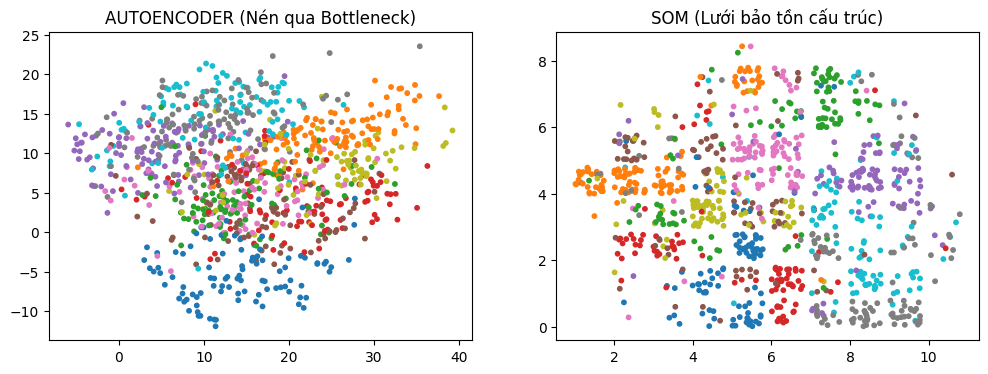

In [26]:
# ==========================================
# BƯỚC 4: KỶ NGUYÊN NEURAL NETWORK
# ==========================================
from keras.models import Model
from keras.layers import Input, Dense
from minisom import MiniSom # Nhớ pip install minisom trước nhé

# 4.1. AUTOENCODER (Mạng nơ-ron hình phễu)
print("Đang huấn luyện Autoencoder...")
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
bottleneck = Dense(2, activation='linear')(encoded) # Nút thắt cổ chai 2D
decoded = Dense(128, activation='relu')(bottleneck)
output_img = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, output_img)
encoder = Model(input_img, bottleneck) # Lấy phần phễu nén
autoencoder.compile(optimizer='adam', loss='mse')

# Train theo batch nhỏ (128) -> Không bao giờ lo tràn RAM
autoencoder.fit(x_flat[:5000], x_flat[:5000], epochs=10, batch_size=128, verbose=0)
ae_result = encoder.predict(x_flat[:1000])

# 4.2. SELF-ORGANIZING MAPS (Tấm lưới bảo tồn Topology)
print("Đang huấn luyện SOM...")
som = MiniSom(15, 15, 784, sigma=1.0, learning_rate=0.5, random_seed=42)
som.train_random(x_flat[:1000], 500)
som_result = np.array([som.winner(x) for x in x_flat[:1000]])

# Vẽ so sánh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(ae_result[:, 0], ae_result[:, 1], c=y_small, cmap='tab10', s=10)
axes[0].set_title("AUTOENCODER (Nén qua Bottleneck)")

# Cộng thêm chút nhiễu (jitter) để điểm SOM không đè bẹp lên nhau tại tọa độ nguyên
jitter = np.random.rand(*som_result.shape) * 0.8
axes[1].scatter(som_result[:, 0] + jitter[:, 0], som_result[:, 1] + jitter[:, 1], c=y_small, cmap='tab10', s=10)
axes[1].set_title("SOM (Lưới bảo tồn cấu trúc)")
plt.show()

In [27]:
# ==========================================
# BƯỚC 5: GIẢI CỨU BIG DATA BẰNG INCREMENTAL PCA
# ==========================================
from sklearn.decomposition import IncrementalPCA

print("Bắt đầu xử lý Big Data khổng lồ...")

# Khởi tạo Incremental PCA
ipca = IncrementalPCA(n_components=2)

# Trả lời bài toán ở Bước 1: Không nhồi hết dữ liệu vào RAM để tính Hiệp phương sai nữa!
# Ta chia 60.000 dòng thành các Lô (Chunks) nhỏ, mỗi lô 5000 dòng.
chunk_size = 5000
for i in range(0, 60000, chunk_size):
    # Trích xuất 1 lô dữ liệu
    x_chunk = x_flat[i : i + chunk_size]
    
    # partial_fit: Chạy PCA trên lô này rồi CẬP NHẬT ĐỆ QUY kết quả cũ
    ipca.partial_fit(x_chunk)
    print(f"-> Đã xử lý và cập nhật xong lô từ {i} đến {i + chunk_size}...")

# Biến đổi toàn bộ tập dữ liệu cực kỳ nhẹ nhàng
ipca_result = ipca.transform(x_flat[:2000])

print("\nThành công! Toàn bộ quá trình chạy PCA mà RAM máy tính gần như không suy suyển.")

Bắt đầu xử lý Big Data khổng lồ...
-> Đã xử lý và cập nhật xong lô từ 0 đến 5000...
-> Đã xử lý và cập nhật xong lô từ 5000 đến 10000...
-> Đã xử lý và cập nhật xong lô từ 10000 đến 15000...
-> Đã xử lý và cập nhật xong lô từ 15000 đến 20000...
-> Đã xử lý và cập nhật xong lô từ 20000 đến 25000...
-> Đã xử lý và cập nhật xong lô từ 25000 đến 30000...
-> Đã xử lý và cập nhật xong lô từ 30000 đến 35000...
-> Đã xử lý và cập nhật xong lô từ 35000 đến 40000...
-> Đã xử lý và cập nhật xong lô từ 40000 đến 45000...
-> Đã xử lý và cập nhật xong lô từ 45000 đến 50000...
-> Đã xử lý và cập nhật xong lô từ 50000 đến 55000...
-> Đã xử lý và cập nhật xong lô từ 55000 đến 60000...

Thành công! Toàn bộ quá trình chạy PCA mà RAM máy tính gần như không suy suyển.
